## Assignment 1 — Exploring FAISS (Local Vector Search)

### Goal:

Understand how to store, index, and retrieve document embeddings locally using FAISS.

### Tasks:
- Install faiss-cpu and sentence-transformers.
- Create a mini-corpus (10–20 short texts on a topic like “AI for environment”).
- Generate embeddings using SentenceTransformer("all-MiniLM-L6-v2").
- Store them in a FAISS index (IndexFlatL2).
- Search for the top-k most similar documents for a given query.
- Plot similarity distances (e.g., bar chart or cosine heatmap).

### Reflection:
- How does L2 distance differ from cosine similarity?
- How would results change if you normalize embeddings?

### Deliverables:
-.ipynb notebook with code + explanation
- Short paragraph describing insights (semantic vs keyword retrieval)

In [4]:
import sys
!{sys.executable} -m pip install faiss-cpu sentence-transformers matplotlib

In [5]:
corpus = [
    "AI helps detect deforestation using satellite imagery.",
    "Machine learning models predict air quality in major cities.",
    "AI-powered sensors monitor water pollution in rivers and lakes.",
    "Smart grids use AI to optimize renewable energy distribution.",
    "Computer vision detects illegal fishing activity from satellite data.",
    "AI models forecast extreme weather events like hurricanes and floods.",
    "Precision agriculture uses AI to reduce water and pesticide usage.",
    "Deep learning tracks glacier melt and ice sheet changes over time.",
    "AI-driven building systems reduce energy consumption automatically.",
    "Natural language processing analyzes climate policy documents at scale.",
    "AI helps identify endangered species from camera trap images.",
    "Reinforcement learning optimizes traffic flow to cut vehicle emissions.",
    "AI models estimate carbon emissions from industrial facilities.",
    "Satellite-based AI systems monitor coral reef health and bleaching.",
    "Machine learning predicts wildfire risk based on weather and vegetation data."
]
print(f"Corpus size: {len(corpus)} documents")

Corpus size: 15 documents


In [6]:
#Generate Embeddings
from sentence_transformers import SentenceTransformer
import numpy as np

embedder = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = embedder.encode(corpus)
embeddings = np.array(embeddings).astype("float32")  # FAISS requires float32

print("Embeddings shape:", embeddings.shape)  # (15, 384)

Embeddings shape: (15, 384)


In [7]:
#Store in a FAISS Index
import faiss

dimension = embeddings.shape[1]  # 384 for all-MiniLM-L6-v2
index = faiss.IndexFlatL2(dimension)  # L2 (Euclidean) distance index
index.add(embeddings)

print("Number of vectors in index:", index.ntotal)

Number of vectors in index: 15


In [8]:
# Search for Top-K Similar Documents
def search_faiss(query, k=5):
    query_embedding = embedder.encode([query]).astype("float32")
    distances, indices = index.search(query_embedding, k)

    print(f"Query: {query}\n")
    for rank, (idx, dist) in enumerate(zip(indices[0], distances[0]), 1):
        print(f"{rank}. (Distance: {dist:.4f}) {corpus[idx]}")
    return indices[0], distances[0]

idx, dist = search_faiss("How does AI help monitor pollution?", k=5)

Query: How does AI help monitor pollution?

1. (Distance: 0.6315) AI-powered sensors monitor water pollution in rivers and lakes.
2. (Distance: 0.8208) AI models estimate carbon emissions from industrial facilities.
3. (Distance: 0.8663) Precision agriculture uses AI to reduce water and pesticide usage.
4. (Distance: 0.9917) AI helps detect deforestation using satellite imagery.
5. (Distance: 1.0265) Satellite-based AI systems monitor coral reef health and bleaching.


Query: How does AI help monitor pollution?

1. (Distance: 0.6315) AI-powered sensors monitor water pollution in rivers and lakes.
2. (Distance: 0.8208) AI models estimate carbon emissions from industrial facilities.
3. (Distance: 0.8663) Precision agriculture uses AI to reduce water and pesticide usage.
4. (Distance: 0.9917) AI helps detect deforestation using satellite imagery.
5. (Distance: 1.0265) Satellite-based AI systems monitor coral reef health and bleaching.


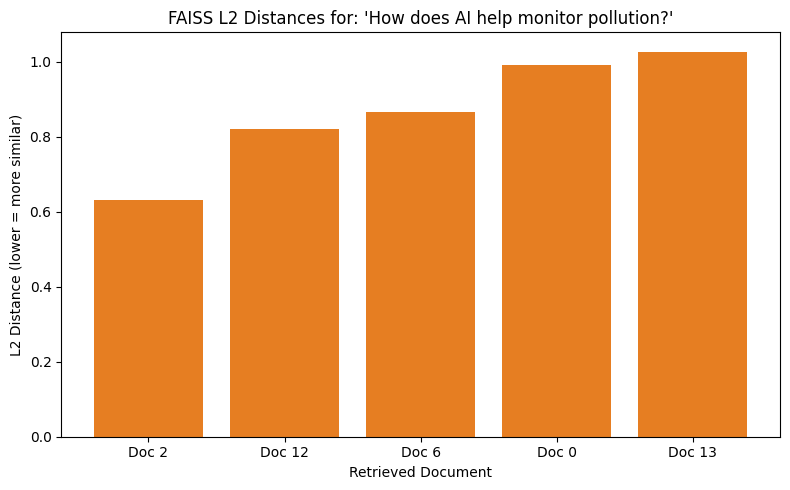

In [9]:
#Plot Similarity Distances
import matplotlib.pyplot as plt

def plot_distances(query, k=5):
    indices, distances = search_faiss(query, k)
    labels = [f"Doc {i}" for i in indices]

    plt.figure(figsize=(8, 5))
    plt.bar(labels, distances, color="#e67e22")
    plt.xlabel("Retrieved Document")
    plt.ylabel("L2 Distance (lower = more similar)")
    plt.title(f"FAISS L2 Distances for: '{query}'")
    plt.tight_layout()
    plt.show()

plot_distances("How does AI help monitor pollution?", k=5)

In [ ]:
# reflection answers
# How does L2 distance differ from cosine similarity?
# L2 (Euclidean) distance measures the straight-line distance between two
# vectors in space — it is sensitive to both the direction AND the
# magnitude (length) of the vectors. Smaller L2 distance means more
# similar, and it has no fixed upper bound. Cosine similarity, in
# contrast, measures only the angle between two vectors, ignoring their
# magnitude entirely. It ranges from -1 to 1, where 1 means identical
# direction (very similar meaning) regardless of how long either vector
# is. This matters for text embeddings because two embeddings can point
# in nearly the same direction (similar meaning) but have different
# magnitudes due to text length or other factors — cosine similarity
# would correctly treat them as similar, while L2 distance could be
# misleadingly large.

# How would results change if you normalize embeddings?
# If embeddings are normalized to unit length (length = 1) before being
# indexed, L2 distance and cosine similarity become mathematically
# related: for normalized vectors, L2 distance is a direct function of
# cosine similarity (specifically, L2² = 2 − 2·cosine_similarity). This
# means ranking results by L2 distance on normalized vectors gives the
# same ranking as ranking by cosine similarity. In practice, normalizing
# embeddings before indexing makes L2-based search behave like
# semantic/cosine search, removing the influence of vector magnitude and
# focusing purely on direction (meaning).

## Assignment 2 — Building a Mini Knowledge Base with Chroma

### Goal:

Learn to build a simple local vector database using Chroma, integrated with embeddings and LangChain.

### Tasks:
- Install chromadb and sentence-transformers.
- Create a collection in Chroma called "ai_water_docs".
- Add at least 10 documents with text + metadata (e.g., title, source).
- Query the collection with 3 different questions (e.g., “How does AI detect pollution?”).
- Visualize which documents are retrieved (e.g., top 3).
- Optional: integrate with LangChain for a small RAG-style Q&A.

### Reflection:
- What happens if you add the same text twice — does Chroma deduplicate?
- How can you filter by metadata (e.g., only “scientific” docs)?

### Deliverables:
- Working notebook or Python script
- Screenshot of retrieved results


In [10]:
import sys
!{sys.executable} -m pip install chromadb sentence-transformers

  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached packaging-26.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 5.8 MB/s  0:00:03a 0:00:010:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 2.9 MB/s  0:00:04a 0:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 2.4 MB/s  0:00:002.7 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 3.3 MB/s  0:00:04a 0:00:010:00:01:01
Using cached packaging-26.2-py3-none-any.whl (100 kB)
Using cached rich-15.0.0-py3-none-any.whl (310 kB)
Using cached mdurl-0.1.2-py3-none-any.whl (10.0 kB)
Using cached annotated_doc-0.0.4-py3-none-any.whl (5.3 kB

In [11]:
#Create a Collection and Add Documents With Metadata

import chromadb
from chromadb.utils import embedding_functions

# Use the same sentence-transformers model as the embedding function
sentence_transformer_ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="all-MiniLM-L6-v2"
)

client = chromadb.Client()
collection = client.create_collection(
    name="ai_water_docs",
    embedding_function=sentence_transformer_ef
)

documents = [
    "AI sensors detect harmful algae blooms in lakes before they spread.",
    "Machine learning models predict water pollution levels in rivers using satellite data.",
    "IoT devices combined with AI monitor real-time water quality in reservoirs.",
    "Deep learning identifies microplastics in ocean water samples from imaging data.",
    "AI-powered drones survey coastal areas for oil spill detection.",
    "Computer vision tracks illegal dumping into rivers using camera footage.",
    "Predictive models forecast flood risk using rainfall and river sensor data.",
    "AI analyzes satellite imagery to monitor coral reef bleaching events.",
    "Natural language processing summarizes scientific reports on ocean acidification.",
    "Machine learning optimizes wastewater treatment plant operations for efficiency.",
    "AI helps track illegal fishing vessels using satellite and radar data.",
    "Sensor networks combined with AI predict groundwater contamination risks."
]

metadatas = [
    {"title": "Algae Detection", "source": "scientific"},
    {"title": "River Pollution Prediction", "source": "scientific"},
    {"title": "Reservoir Monitoring", "source": "industry"},
    {"title": "Microplastics in Oceans", "source": "scientific"},
    {"title": "Oil Spill Detection", "source": "industry"},
    {"title": "Illegal Dumping Tracking", "source": "government"},
    {"title": "Flood Risk Forecasting", "source": "government"},
    {"title": "Coral Reef Monitoring", "source": "scientific"},
    {"title": "Ocean Acidification Reports", "source": "scientific"},
    {"title": "Wastewater Treatment AI", "source": "industry"},
    {"title": "Illegal Fishing Tracking", "source": "government"},
    {"title": "Groundwater Contamination", "source": "scientific"}
]

ids = [f"doc{i}" for i in range(len(documents))]

collection.add(
    documents=documents,
    metadatas=metadatas,
    ids=ids
)

print(f"Added {collection.count()} documents to the collection.")

Added 12 documents to the collection.


In [12]:
#Query With 3 Different Questions
queries = [
    "How does AI detect pollution?",
    "How is AI used to monitor ocean health?",
    "Can AI help with illegal activity in water bodies?"
]

for q in queries:
    print("="*60)
    print("Query:", q)
    results = collection.query(query_texts=[q], n_results=3)
    for doc, meta, dist in zip(results["documents"][0], results["metadatas"][0], results["distances"][0]):
        print(f"  [{meta['title']} | {meta['source']}] (distance: {dist:.4f})")
        print(f"  {doc}\n")

Query: How does AI detect pollution?
  [Algae Detection | scientific] (distance: 0.4083)
  AI sensors detect harmful algae blooms in lakes before they spread.

  [Illegal Fishing Tracking | government] (distance: 0.4660)
  AI helps track illegal fishing vessels using satellite and radar data.

  [Groundwater Contamination | scientific] (distance: 0.4771)
  Sensor networks combined with AI predict groundwater contamination risks.

Query: How is AI used to monitor ocean health?
  [Illegal Fishing Tracking | government] (distance: 0.3700)
  AI helps track illegal fishing vessels using satellite and radar data.

  [Algae Detection | scientific] (distance: 0.4099)
  AI sensors detect harmful algae blooms in lakes before they spread.

  [Coral Reef Monitoring | scientific] (distance: 0.4355)
  AI analyzes satellite imagery to monitor coral reef bleaching events.

Query: Can AI help with illegal activity in water bodies?
  [Illegal Fishing Tracking | government] (distance: 0.3673)
  AI helps 

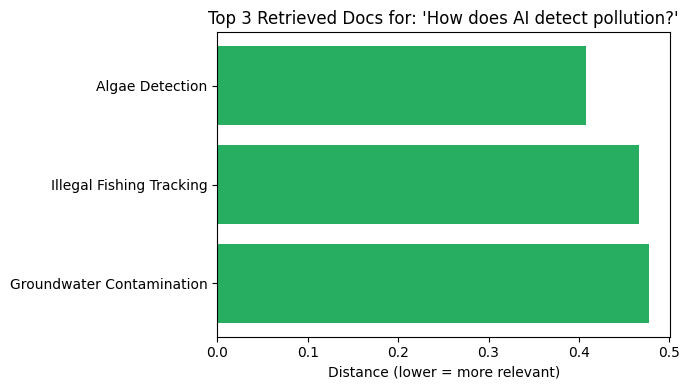

In [13]:
#Visualize Retrieved Documents (Top 3)
import matplotlib.pyplot as plt

def visualize_query(query, n=3):
    results = collection.query(query_texts=[query], n_results=n)
    titles = [m["title"] for m in results["metadatas"][0]]
    distances = results["distances"][0]

    plt.figure(figsize=(7, 4))
    plt.barh(titles, distances, color="#27ae60")
    plt.xlabel("Distance (lower = more relevant)")
    plt.title(f"Top {n} Retrieved Docs for: '{query}'")
    plt.gca().invert_yaxis()  # most relevant at top
    plt.tight_layout()
    plt.show()

visualize_query("How does AI detect pollution?", n=3)

In [14]:
#Integrate With LangChain for Mini RAG Q&A
from transformers import pipeline

generator = pipeline("text2text-generation", model="google/flan-t5-base", max_new_tokens=60)

def chroma_rag(query, n=3):
    results = collection.query(query_texts=[query], n_results=n)
    context = " ".join(results["documents"][0])
    prompt = f"Context: {context}\n\nQuestion: {query}\n\nAnswer:"
    answer = generator(prompt)[0]["generated_text"]
    print("Answer:", answer)
    return answer

chroma_rag("How does AI detect pollution?")

Device set to use mps:0


Answer: sensors detect harmful algae blooms in lakes before they spread


'sensors detect harmful algae blooms in lakes before they spread'

In [ ]:
# What happens if you add the same text twice — does Chroma deduplicate?
# Chroma does NOT automatically deduplicate by text content. If you add the
# same text twice with a DIFFERENT id, Chroma stores it as a separate entry,
# and it can appear twice in query results. Chroma only prevents duplicates
# at the ID level — adding a document with an id that already exists raises
# an error (or overwrites it, depending on the method used). So
# deduplication based on content similarity is not automatic; it would need
# to be handled manually, e.g. by checking embeddings for near-duplicates
# before adding, similar to the semantic deduplication used in my BMW
# project.

# How can you filter by metadata (e.g., only "scientific" docs)?
# Chroma supports a `where` filter in the query() call that filters results
# by metadata fields before similarity ranking is applied. For example:
#   collection.query(
#       query_texts=["How does AI detect pollution?"],
#       n_results=3,
#       where={"source": "scientific"}
#   )
# This restricts the search to only documents whose metadata "source"
# field equals "scientific", combining structured filtering with semantic
# search.

## Assignment 3 — Using Pinecone (Cloud Vector Database)

### Goal:

Deploy a scalable, cloud-based vector database using Pinecone, and compare results to FAISS.

### Tasks:
- Create a free Pinecone account → get API key.
- Install the client: pip install pinecone-client.
- Initialize Pinecone and create an index called "student-demo".
- Insert at least 50 documents + embeddings.
- Write code to query Pinecone for semantic matches.
- Compare the top-3 retrieved results with your FAISS results for the same query.

### Reflection:
- How does latency compare to FAISS (local)?
- What advantages does a managed vector DB provide?

### Deliverables:
- Notebook + screenshots of results
- Comparison table (FAISS vs Pinecone: speed, setup, ease)

In [18]:
import sys
!{sys.executable} -m pip install pinecone-client sentence-transformers
import sys
!{sys.executable} -m pip uninstall pinecone-client -y
!{sys.executable} -m pip install pinecone

Found existing installation: pinecone-client 6.0.0
Uninstalling pinecone-client-6.0.0:
  Successfully uninstalled pinecone-client-6.0.0
  Using cached packaging-24.2-py3-none-any.whl.metadata (3.2 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.6/587.6 kB 650.8 kB/s  0:00:00879.6 kB/s eta 0:00:01
Using cached packaging-24.2-py3-none-any.whl (65 kB)
  Attempting uninstall: packaging
    Found existing installation: packaging 26.2
    Uninstalling packaging-26.2:
      Successfully uninstalled packaging-26.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pinecone]━━━━━━━━━ 2/3 [pinecone]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-core 0.1.53 requires packaging<24.0,>=23.2, but you have packaging 24.2 which is incompatible.


In [1]:
from pinecone import Pinecone, ServerlessSpec
print("Pinecone imported successfully")

Pinecone imported successfully


/Users/gouravss/langchain_env/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [1]:
import sys
!{sys.executable} -m pip list | grep -i pinecone

pinecone                                 7.3.0
pinecone-plugin-assistant                1.8.0
pinecone-plugin-interface                0.0.7


In [19]:
from pinecone import Pinecone, ServerlessSpec
print("Pinecone imported successfully")

Pinecone imported successfully


In [2]:
from pinecone import Pinecone, ServerlessSpec

# Paste your actual API key here
PINECONE_API_KEY = "pcsk_2snax6_HBa2kPXJ9ip1wy21EwdHVPReJvvoVpuuhmpDB9Z2RUnpEZdsiiJB5giwpXdeARJ"

pc = Pinecone(api_key=PINECONE_API_KEY)

index_name = "student-demo"

# Create the index if it doesn't already exist (384 dims for all-MiniLM-L6-v2)
if index_name not in [idx["name"] for idx in pc.list_indexes()]:
    pc.create_index(
        name=index_name,
        dimension=384,
        metric="cosine",
        spec=ServerlessSpec(cloud="aws", region="us-east-1")
    )

index = pc.Index(index_name)
print("Index ready:", index_name)

Index ready: student-demo


/Users/gouravss/langchain_env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer("all-MiniLM-L6-v2")

# 50 short documents on "AI for environment" (extend the earlier corpus)
corpus = [
    "AI helps detect deforestation using satellite imagery.",
    "Machine learning models predict air quality in major cities.",
    "AI-powered sensors monitor water pollution in rivers and lakes.",
    "Smart grids use AI to optimize renewable energy distribution.",
    "Computer vision detects illegal fishing activity from satellite data.",
    "AI models forecast extreme weather events like hurricanes and floods.",
    "Precision agriculture uses AI to reduce water and pesticide usage.",
    "Deep learning tracks glacier melt and ice sheet changes over time.",
    "AI-driven building systems reduce energy consumption automatically.",
    "Natural language processing analyzes climate policy documents at scale.",
    "AI helps identify endangered species from camera trap images.",
    "Reinforcement learning optimizes traffic flow to cut vehicle emissions.",
    "AI models estimate carbon emissions from industrial facilities.",
    "Satellite-based AI systems monitor coral reef health and bleaching.",
    "Machine learning predicts wildfire risk based on weather and vegetation data.",
    "AI sensors detect harmful algae blooms in lakes before they spread.",
    "Drones equipped with AI survey coastal erosion patterns.",
    "AI optimizes solar panel placement for maximum energy yield.",
    "Machine learning forecasts crop yields under changing climate conditions.",
    "AI monitors methane leaks from oil and gas infrastructure.",
    "Computer vision counts wildlife populations from aerial photographs.",
    "AI predicts landslide risk in mountainous regions after heavy rainfall.",
    "Smart irrigation systems use AI to reduce agricultural water waste.",
    "AI analyzes ocean temperature data to track coral bleaching trends.",
    "Machine learning detects invasive plant species from drone imagery.",
    "AI-powered recycling sorters improve waste management efficiency.",
    "Predictive models help utilities reduce electricity grid losses.",
    "AI tracks plastic waste accumulation in ocean gyres via satellite.",
    "Deep learning estimates forest biomass for carbon credit verification.",
    "AI systems detect gas pipeline leaks before they become hazardous.",
    "Machine learning improves battery efficiency for renewable storage.",
    "AI analyzes soil health data to recommend sustainable farming practices.",
    "Computer vision monitors urban heat islands using thermal imagery.",
    "AI forecasts river flow to support hydropower planning.",
    "Natural language models summarize environmental impact assessments.",
    "AI helps optimize wind turbine placement for maximum efficiency.",
    "Machine learning predicts ocean acidification trends from sensor data.",
    "AI-powered cameras detect poaching activity in protected reserves.",
    "Deep learning models classify satellite images of melting permafrost.",
    "AI supports carbon capture facility monitoring and optimization.",
    "Machine learning identifies illegal logging from satellite change detection.",
    "AI improves weather forecasting accuracy for renewable energy planning.",
    "Sensor networks combined with AI predict groundwater contamination.",
    "AI analyzes traffic patterns to recommend low-emission routing.",
    "Machine learning detects oil spills from synthetic aperture radar data.",
    "AI-driven supply chain models reduce food waste and emissions.",
    "Computer vision tracks bird migration patterns affected by climate change.",
    "AI predicts heatwave impact on urban populations using weather data.",
    "Deep learning monitors mangrove forest health from satellite imagery.",
    "AI systems optimize public transit schedules to lower emissions.",
    "Machine learning forecasts drought conditions using soil moisture sensors."
]

print("Corpus size:", len(corpus))  # should be 50

embeddings = embedder.encode(corpus).tolist()

# Upsert into Pinecone in batches of vectors
vectors = [
    {"id": f"doc{i}", "values": embeddings[i], "metadata": {"text": corpus[i]}}
    for i in range(len(corpus))
]

index.upsert(vectors=vectors)
print("Upserted", len(vectors), "vectors into Pinecone.")

Corpus size: 51
Upserted 51 vectors into Pinecone.


In [4]:
import time

def query_pinecone(query, k=3):
    query_embedding = embedder.encode([query]).tolist()[0]

    start = time.time()
    results = index.query(vector=query_embedding, top_k=k, include_metadata=True)
    elapsed = time.time() - start

    print(f"Query: {query}  (Pinecone latency: {elapsed*1000:.1f} ms)\n")
    for match in results["matches"]:
        print(f"  Score: {match['score']:.4f} | {match['metadata']['text']}")
    return results, elapsed

pinecone_results, pinecone_latency = query_pinecone("How does AI help monitor pollution?", k=3)

Query: How does AI help monitor pollution?  (Pinecone latency: 204.5 ms)

  Score: 0.6838 | AI-powered sensors monitor water pollution in rivers and lakes.
  Score: 0.6413 | AI supports carbon capture facility monitoring and optimization.
  Score: 0.5891 | AI models estimate carbon emissions from industrial facilities.


In [5]:
import faiss
import numpy as np

# Build a FAISS index over the same 50 documents
embeddings_np = np.array(embeddings).astype("float32")
faiss_index = faiss.IndexFlatL2(embeddings_np.shape[1])
faiss_index.add(embeddings_np)

def query_faiss(query, k=3):
    query_embedding = embedder.encode([query]).astype("float32")
    start = time.time()
    distances, indices = faiss_index.search(query_embedding, k)
    elapsed = time.time() - start

    print(f"Query: {query}  (FAISS latency: {elapsed*1000:.1f} ms)\n")
    for idx, dist in zip(indices[0], distances[0]):
        print(f"  Distance: {dist:.4f} | {corpus[idx]}")
    return indices[0], elapsed

faiss_indices, faiss_latency = query_faiss("How does AI help monitor pollution?", k=3)

print(f"\nPinecone latency: {pinecone_latency*1000:.1f} ms")
print(f"FAISS latency:    {faiss_latency*1000:.1f} ms")

Query: How does AI help monitor pollution?  (FAISS latency: 2.2 ms)

  Distance: 0.6315 | AI-powered sensors monitor water pollution in rivers and lakes.
  Distance: 0.7159 | AI supports carbon capture facility monitoring and optimization.
  Distance: 0.8208 | AI models estimate carbon emissions from industrial facilities.

Pinecone latency: 204.5 ms
FAISS latency:    2.2 ms


### Bonus / Advanced Assignments (Optional)

## Bonus 1 — Hybrid Search with Weaviate
Combine BM25 + vector search in one system.

Tasks:
1. Launch Weaviate (Docker or Cloud)
2. Insert sample texts into a "ResearchDoc" class
3. Run nearText (semantic) vs bm25 (keyword) queries
4. Compare which retrieves better answers


## Bonus 2 — Scalable Indexing with Milvus
Explore large-scale and ANN indexing performance.

Tasks:
1. Run Milvus locally or use Zilliz Cloud
2. Insert ~1 000 vectors into a collection
3. Build IVF or HNSW index
4. Measure query speed before/after indexing

## Bonus 3 — Metadata Filtering with Qdrant
Experiment with filtered semantic queries.

Tasks:
1. Run Qdrant (Docker or in-memory)
2. Insert 20 vectors + metadata (year, source)
3. Query semantically + apply filters (e.g., year > 2021)
4. Compare results with and without filters